<a href="https://colab.research.google.com/github/mkolennikova/TEB-Ru/blob/main/run_in_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import os, sys, shutil, glob, time
import subprocess
import importlib
import pandas as pd
from pathlib import Path

def import_and_reload (module_name: str):
    """Loads a module by name, or reloads it if already imported."""
    if module_name in sys.modules:
        print(f"Reloading existing module: {module_name}")
        return importlib.reload(sys.modules[module_name])
    else:
        print(f"Loading new module: {module_name}")
        return importlib.import_module(module_name)


In [30]:
opts = {'use_gdrive': False,
        'update_repo': True,
        'repo_path': 'https://github.com/mkolennikova/TEB-Ru'}

opts['model_name'] = os.path.basename(os.path.normpath(opts['repo_path']))

In [25]:
if opts['use_gdrive']:
  from google.colab import drive
  drive.mount('/content/drive')
  WORK_DIR = '/content/drive/MyDrive/TEB_work'
else:
  WORK_DIR = '/content/TEB_work'

MODEL_DIR = WORK_DIR + '/' + opts['model_name']

os.makedirs(WORK_DIR, exist_ok = True)


In [36]:
os.chdir (WORK_DIR)
if not os.path.isdir (opts['model_name']) or opts['update_repo']:
  if os.path.isdir (opts['model_name']):
    %rm -r {opts['model_name']}
  !git clone {opts['repo_path']}
else:
  os.chdir(MODEL_DIR)
  !git pull



Cloning into 'TEB-Ru'...
remote: Enumerating objects: 301, done.
remote: Counting objects: 100% (301/301), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 301 (delta 118), reused 271 (delta 92), pack-reused 0 (from 0)
Receiving objects: 100% (301/301), 2.30 MiB | 9.13 MiB/s, done.
Resolving deltas: 100% (118/118), done.


In [42]:
sys.path.append (MODEL_DIR + '/python/')
import install_utils

install_utils.import_extrernal_modules()


'f90nml' exists.
'cdsapi' exists.


In [23]:
install_utils.init_CDS()

Enter the URL of the CDS API (if empty, will use default): 
Enter your API key: a94b04c7-f0a6-4146-952a-1e116ed0b8c4


Reloading existing module: forcing_ERA5
📥 Downloading ERA5 data for (55.030204, 82.92043) from 2024-01-01 to 2024-12-31...


2026-06-24 09:31:23,431 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
INFO:ecmwf.datastores.legacy_client:[2026-02-16T00:00:00] - To generate this ERA5 hourly time series datase

c392ce0f4ae0fd86d481878c82c35ff2.zip:   0%|          | 0.00/441k [00:00<?, ?B/s]

✅ Extracted and saved to Novosibirsk/netcdf/era5_2024-01-01_2024-12-31.nc
✅ Downloaded 1 file(s) to Novosibirsk/netcdf
📊 Preparing forcing DataFrame...
DataFrame saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.csv
✅ DataFrame saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.csv
💾 Writing forcing text files...


Saving forcing variables: 100%|██████████| 11/11 [00:00<00:00, 80.33it/s]

✅ Forcing files written to Novosibirsk/forcing
📈 Generating plot...
Auto-resampling to daily (number of points: 8784)


Plot saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.png


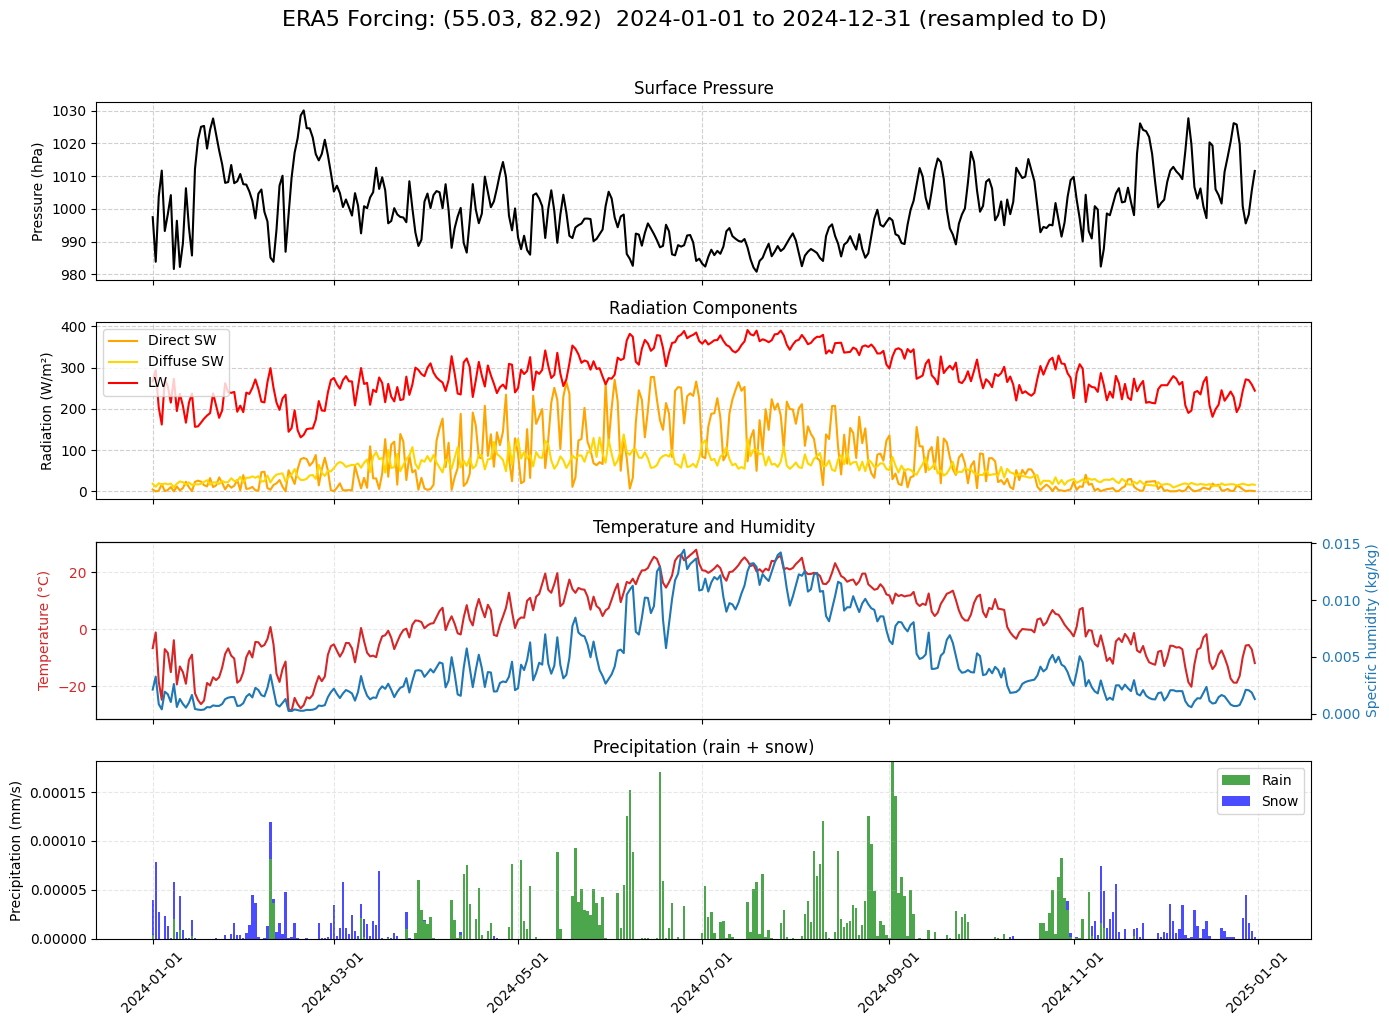

✅ Plot saved to Novosibirsk/era5_forcing_2024-01-01_2024-12-31.png


In [44]:
forcing_ERA5 = import_and_reload ('forcing_ERA5')

forcing_params = dict(lat = 55.030204,
                      lon = 82.920430,
                      base_dir = 'Novosibirsk',
                      start_date = '2024-01-01',
                      end_date = '2024-12-31',
                      time = '1h')


forcing_ERA5.prepare_forcing (**forcing_params)

## Model compilation

In [62]:
start_time = time.time()

!make -C {MODEL_DIR} clean > {MODEL_DIR}/make_clean_output.txt 2>&1
!make -C {MODEL_DIR} all > {MODEL_DIR}/make_all_output.txt 2>&1

new_files = [f for f in glob.glob(MODEL_DIR + '/*.*') if os.path.getmtime(f) >= start_time]

print('Compilation finished, new files created:\n' + '\n'.join('\t' + f for f in new_files))

exe_files = [f for f in new_files if f.endswith('.exe')]
if exe_files:
  if len (exe_files) == 1:
    opts['exe_path'] = exe_files[0]
    print (f'✅ Compilation is successfull, executable is {opts['exe_path']}')
  else:
    print ('❌ Something is wrong: there is more than one new executable file')
else:
    print ('❌ Something is wrong: there are not any new executable file')


Compilation finished, new files created:
	/content/TEB_work/TEB-Ru/TEB_offline.exe
	/content/TEB_work/TEB-Ru/make_all_output.txt
	/content/TEB_work/TEB-Ru/make_clean_output.txt
✅ Compilation is successfull, executable is /content/TEB_work/TEB-Ru/TEB_offline.exe
